In [1]:
#All the imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from scipy.stats import kurtosis
from scipy.ndimage import maximum_filter, label
import multiprocessing as mp
import os

In [2]:
#Function Definitions
def partial_x_2d(f,dx):
    """Compute ∂f/∂x using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dx = np.zeros_like(f)
    
    # Central difference in x-direction (axis=0)
    df_dx[1:Nx-1, :] = (f[2:Nx, :] - f[0:Nx-2, :]) / (2 * dx)
    
    # Periodic boundaries (x-direction)
    df_dx[0, :] = (f[1, :] - f[-1, :]) / (2 * dx)
    df_dx[-1, :] = (f[0, :] - f[-2, :]) / (2 * dx)
    
    return df_dx

def partial_y_2d(f,dy):
    """Compute ∂f/∂y using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dy = np.zeros_like(f)
    
    # Central difference in y-direction (axis=1)
    df_dy[:, 1:Ny-1] = (f[:, 2:Ny] - f[:, 0:Ny-2]) / (2 * dy)
    
    # Periodic boundaries (y-direction)
    df_dy[:, 0] = (f[:, 1] - f[:, -1]) / (2 * dy)
    df_dy[:, -1] = (f[:, 0] - f[:, -2]) / (2 * dy)
    
    return df_dy

def partial_x_fft(f, dx):
    """
    Calculate ∂f/∂x using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dx (float): Grid spacing in the x-direction.

    Returns:
        df_dx (2D np.array): Partial derivative ∂f/∂x.
    """
    nx, ny = f.shape
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi  # Wavenumbers in x
    kx = kx[:, np.newaxis]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dx_hat = 1j * kx * f_hat
    df_dx = np.fft.ifft2(df_dx_hat).real

    return np.array(df_dx)

def partial_y_fft(f, dy):
    """
    Calculate ∂f/∂y using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dy (float): Grid spacing in the y-direction.

    Returns:
        df_dy (2D np.array): Partial derivative ∂f/∂y.
    """
    nx, ny = f.shape
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi  # Wavenumbers in y
    ky = ky[np.newaxis, :]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dy_hat = 1j * ky * f_hat
    df_dy = np.fft.ifft2(df_dy_hat).real

    return df_dy

def index_of_just_smaller(arr, value):
    arr = np.asarray(arr)
    mask = arr < value
    if not np.any(mask):
        return None  # No smaller value exists
    return np.argmax(np.where(mask, arr, -np.inf))

In [3]:
# List of simulation directories
sim_dirs = [
    '/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1'
]

dx = 0.0625
dy = 0.0625

In [4]:
def process_sim_dir(sim_dir):
    B_rms = []
    for i in range(0, 300):
        print(f"{sim_dir}: i = {i}", flush=True)

        File_Bx = f'{sim_dir}/Bx_ApJ_t{i}.h5'
        File_By = f'{sim_dir}/By_ApJ_t{i}.h5'

        with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
            data_Bx = fBx['DS1'][:].T
            data_By = fBy['DS1'][:].T

        data_Bp = np.sqrt(data_Bx**2 + data_By**2)
        Bp_rms = np.sqrt(np.mean(data_Bp**2))
        B_rms.append(Bp_rms)

    return sim_dir, B_rms


if __name__ == "__main__":
    with mp.Pool(processes=8) as pool:   # adjust to number of CPU cores
        results = pool.map(process_sim_dir, sim_dirs)

    all_B_rms = {sim_dir: B_rms for sim_dir, B_rms in results}

/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1: i = 0
/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1: i = 1
/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1: i = 2
/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1: i = 3
/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1: i = 4
/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1: i = 5
/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1: i = 6
/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1: i = 7
/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1: i = 8
/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1: i = 9
/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1: i = 10
/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1: i = 11
/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1: i = 12
/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1: i = 13
/h

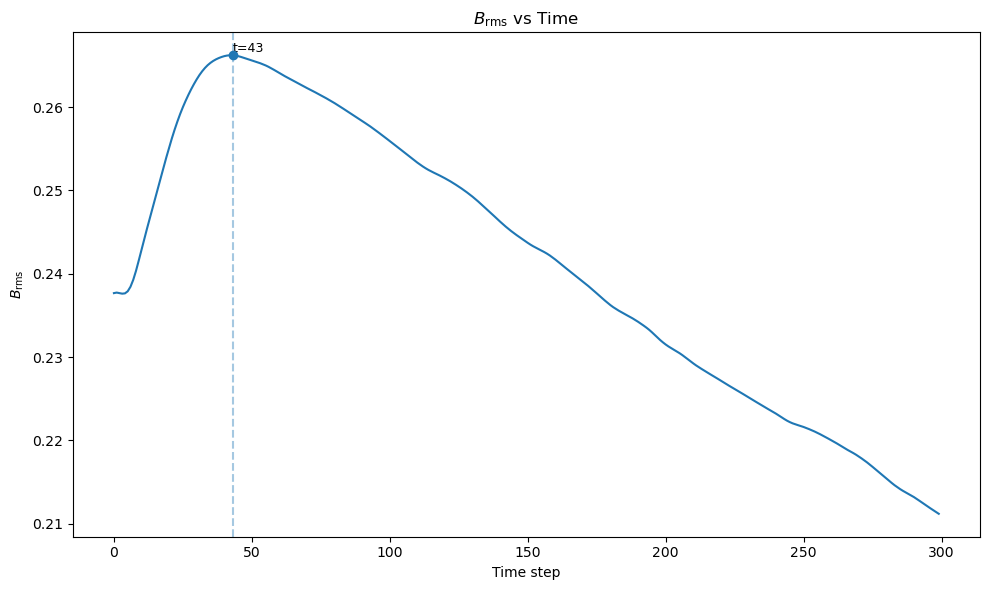

In [5]:
timesteps = np.arange(0, 300)

plt.figure(figsize=(10, 6))

for sim_dir, B_rms in all_B_rms.items():
    B_rms = np.array(B_rms)

    # Plot Brms vs time
    plt.plot(timesteps, B_rms, label=sim_dir)

    # Find peak
    peak_idx = np.argmax(B_rms)
    peak_time = timesteps[peak_idx]
    peak_val = B_rms[peak_idx]

    # Mark the peak
    plt.scatter(peak_time, peak_val, zorder=5)
    plt.axvline(peak_time, linestyle='--', alpha=0.4)

    # Optional: annotate
    plt.text(
        peak_time, peak_val,
        f"t={peak_time}",
        fontsize=9,
        ha='left', va='bottom'
    )

plt.xlabel('Time step')
plt.ylabel(r'$B_{\rm rms}$')
plt.title(r'$B_{\rm rms}$ vs Time')
# plt.legend()
plt.tight_layout()
plt.savefig("Brms.png", dpi=300)
plt.show()